# Dataset: `diabetes.csv`

# 1. Load Data: Import  Diabetes dataset.

In [7]:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


# 2. Data Cleaning: Identify columns where '0' is invalid 
**(Glucose, BloodPressure,SkinThickness, Insulin, BMI) and replace '0' with NaN or the column mean/median**

In [8]:

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

In [9]:
for col in cols:
    print(col, (df[col] == 0).sum()) #to verify 

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


# 3. Feature Selection: Separate features (X) and target (Outcome).

In [10]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 4. Scaling: Apply StandardScaler to the features (KNN is distance-sensitive).

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

# 5. Split Data: Split the data into training and testing sets.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 6. Train KNN: Initialize KNeighborsClassifier (start with K=5) and fit the model.

In [52]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


KNeighborsClassifier()

# 7. Evaluate: Print the accuracy score and confusion matrix.

In [62]:
y_pred = knn.predict(X_test)

from sklearn.metrics import accuracy_score ,confusion_matrix

acc = accuracy_score(y_test,y_pred)
print('Accuracy',acc)

cm = confusion_matrix(y_test,y_pred)
print('Confusion matrix',cm)

Accuracy 0.7337662337662337
Confusion matrix [[38 17]
 [24 75]]


# 8. Hyperparameter Tuning: Use a loop (Elbow Method) to calculate the error rate for K

In [29]:
import matplotlib.pyplot as plt

error_rate = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    error = (y_pred != y_test).mean()
    error_rate.append(error)

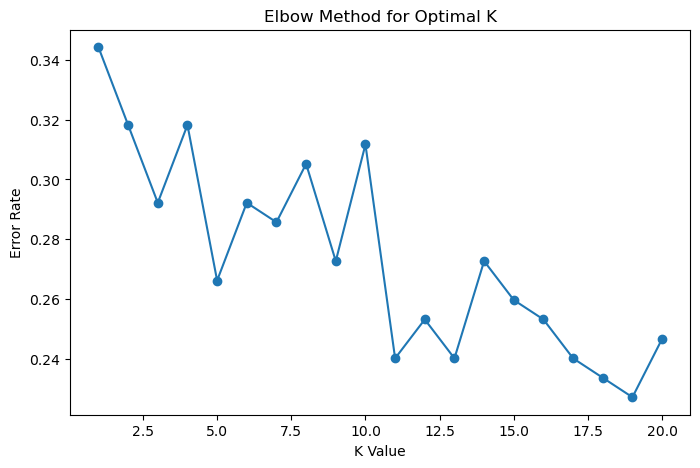

In [31]:
#9. Visualize K: Plot the "Error Rate vs. K Value" graph.

plt.figure(figsize=(8,5))

plt.plot(range(1, 21), error_rate, marker='o')

plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Elbow Method for Optimal K')

plt.show()

In [32]:
best_k = error_rate.index(min(error_rate)) + 1

print("Best k:", best_k)
print("Minimum error rate:", min(error_rate))

Best K: 19
Minimum Error Rate: 0.22727272727272727


In [37]:
for k, error in enumerate(error_rate, start=1):
    print(f"K = {k}, Error Rate = {error:.4f}") # here we can check how eror rates

K = 1, Error Rate = 0.3442
K = 2, Error Rate = 0.3182
K = 3, Error Rate = 0.2922
K = 4, Error Rate = 0.3182
K = 5, Error Rate = 0.2662
K = 6, Error Rate = 0.2922
K = 7, Error Rate = 0.2857
K = 8, Error Rate = 0.3052
K = 9, Error Rate = 0.2727
K = 10, Error Rate = 0.3117
K = 11, Error Rate = 0.2403
K = 12, Error Rate = 0.2532
K = 13, Error Rate = 0.2403
K = 14, Error Rate = 0.2727
K = 15, Error Rate = 0.2597
K = 16, Error Rate = 0.2532
K = 17, Error Rate = 0.2403
K = 18, Error Rate = 0.2338
K = 19, Error Rate = 0.2273
K = 20, Error Rate = 0.2468


# 10. Optimal Model: Retrain the model with the K value that yielded the lowest error.

In [94]:
knn_2 = KNeighborsClassifier(n_neighbors=19)

In [95]:
knn_2.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=19)

In [96]:
y_pred = knn_2.predict(X_test)

In [97]:
acc_2 = accuracy_score(y_test,y_pred)
acc_2

0.7727272727272727